# TEMA1 - Inchiriere Biciclete

### Import-uri

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Incarcare tabel CSV

In [2]:
try:
    df = pd.read_csv("bike_data/train.csv")
    df_test = pd.read_csv("bike_data/test.csv")
    print("fisier incarcat")
except FileNotFoundError:
    print("fisierul nu a fost gasit")

fisier incarcat


### Verificare date lipsa per coloana

In [3]:
print("\nVerificare valori lipsă (per coloană):")
missing_data = df.isnull().sum()
print(missing_data.to_markdown(numalign="left", stralign="left"))
if missing_data.sum() == 0:
    print("\n=> nu există valori lipsă în setul de date")
else:
    print(f'\n=> există {missing_data.sum()} valori lipsă în total în setul de date')


Verificare valori lipsă (per coloană):
|                       | 0   |
|:----------------------|:----|
| data_ora              | 0   |
| sezon                 | 0   |
| sarbatoare            | 0   |
| zi_lucratoare         | 0   |
| vreme                 | 0   |
| temperatura           | 0   |
| temperatura_resimtita | 0   |
| umiditate             | 0   |
| viteza_vant           | 0   |
| ocazionali            | 0   |
| inregistrati          | 0   |
| total                 | 0   |

=> nu există valori lipsă în setul de date


### convertire data_ora la datetime

In [4]:
df['data_ora'] = pd.to_datetime(df['data_ora'])
df.set_index('data_ora', inplace=True)

df_test['data_ora'] = pd.to_datetime(df_test['data_ora'])
df_test.set_index('data_ora', inplace=True)

print(df.head())

                     sezon  sarbatoare  zi_lucratoare  vreme  temperatura  \
data_ora                                                                    
2011-01-01 00:00:00      1           0              0      1         9.84   
2011-01-01 01:00:00      1           0              0      1         9.02   
2011-01-01 02:00:00      1           0              0      1         9.02   
2011-01-01 03:00:00      1           0              0      1         9.84   
2011-01-01 04:00:00      1           0              0      1         9.84   

                     temperatura_resimtita  umiditate  viteza_vant  \
data_ora                                                             
2011-01-01 00:00:00                 14.395         81          0.0   
2011-01-01 01:00:00                 13.635         80          0.0   
2011-01-01 02:00:00                 13.635         80          0.0   
2011-01-01 03:00:00                 14.395         75          0.0   
2011-01-01 04:00:00                 14.3

## Grafice

### Grafic 1: Distributia 'total'

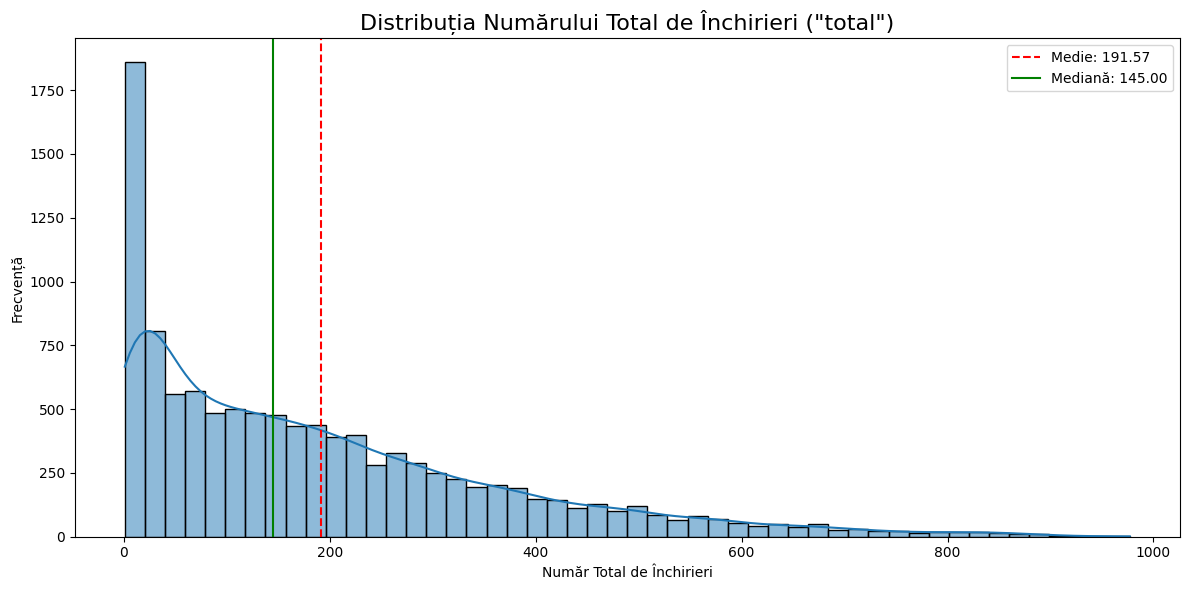

In [5]:
plt.figure(figsize=(12, 6))
sns.histplot(df['total'], kde=True, bins=50)
plt.title('Distribuția Numărului Total de Închirieri ("total")', fontsize=16)
plt.xlabel('Număr Total de Închirieri')
plt.ylabel('Frecvență')
plt.axvline(df['total'].mean(), color='red', linestyle='--', label=f'Medie: {df["total"].mean():.2f}')
plt.axvline(df['total'].median(), color='green', linestyle='-', label=f'Mediană: {df["total"].median():.2f}')
plt.legend()
plt.tight_layout()

### Grafic 2: Distributie logaritmica pentru 'total'

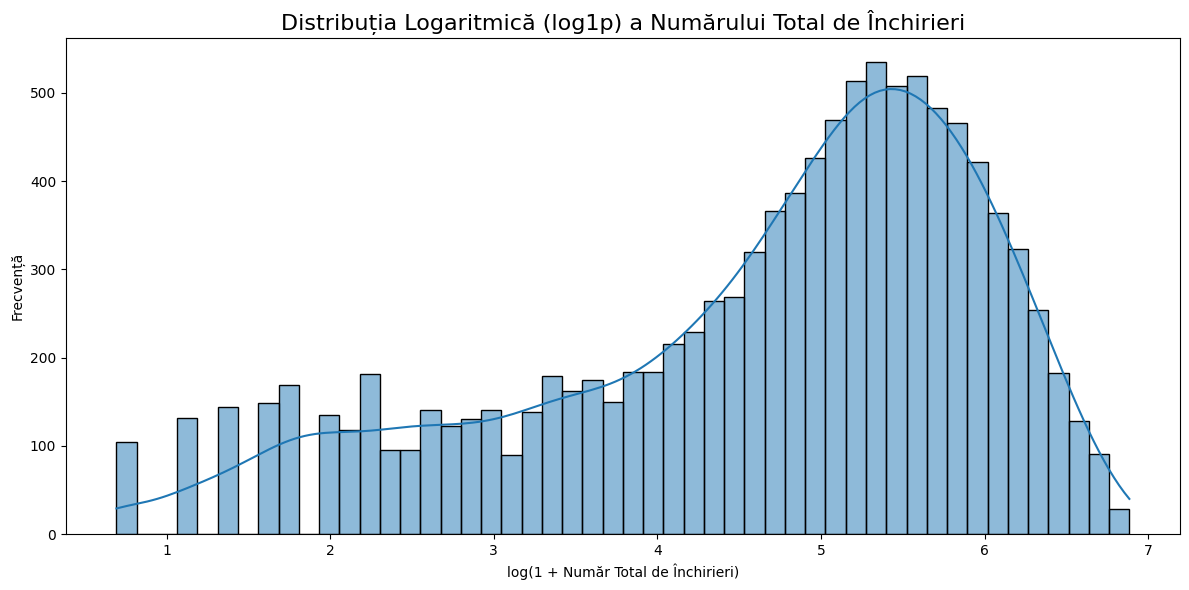

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(df['total']), kde=True, bins=50)
plt.title('Distribuția Logaritmică (log1p) a Numărului Total de Închirieri', fontsize=16)
plt.xlabel('log(1 + Număr Total de Închirieri)')
plt.ylabel('Frecvență')
plt.tight_layout()

### Grafic 3: Serie de timp (zilnic)

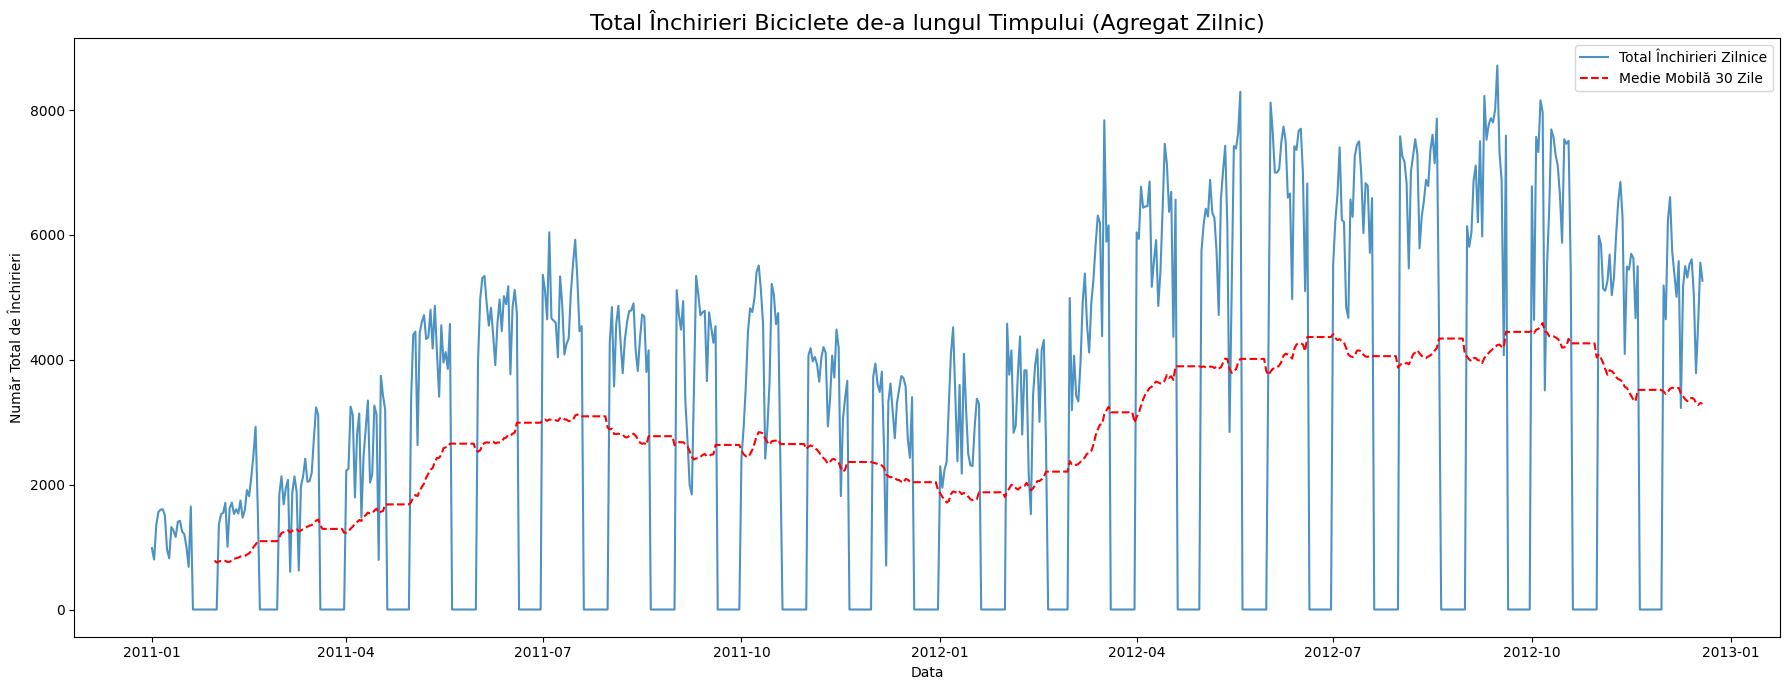

In [7]:
df_daily = df.resample('D').sum()

plt.figure(figsize=(18, 7))
plt.plot(df_daily.index, df_daily['total'], label='Total Închirieri Zilnice', alpha=0.8)
plt.plot(df_daily.index, df_daily['total'].rolling(window=30).mean(), label='Medie Mobilă 30 Zile', color='red', linestyle='--')
plt.title('Total Închirieri Biciclete de-a lungul Timpului (Agregat Zilnic)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Număr Total de Închirieri')
plt.legend()
plt.tight_layout()

### Grafic 4: Heatmat pentru corelatie intre atributele numerice

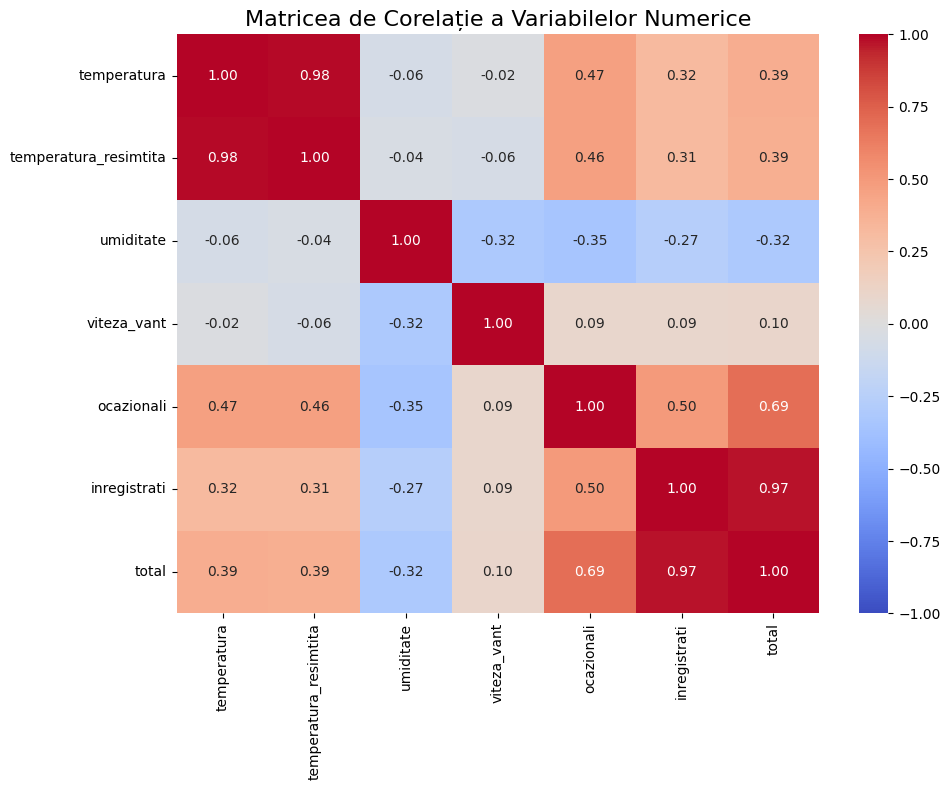

In [8]:
numerical_features = ['temperatura', 'temperatura_resimtita', 'umiditate', 'viteza_vant', 'ocazionali', 'inregistrati', 'total']
    
corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matricea de Corelație a Variabilelor Numerice', fontsize=16)
plt.tight_layout()

### Grafic 5: boxplot pentru atributele categorice

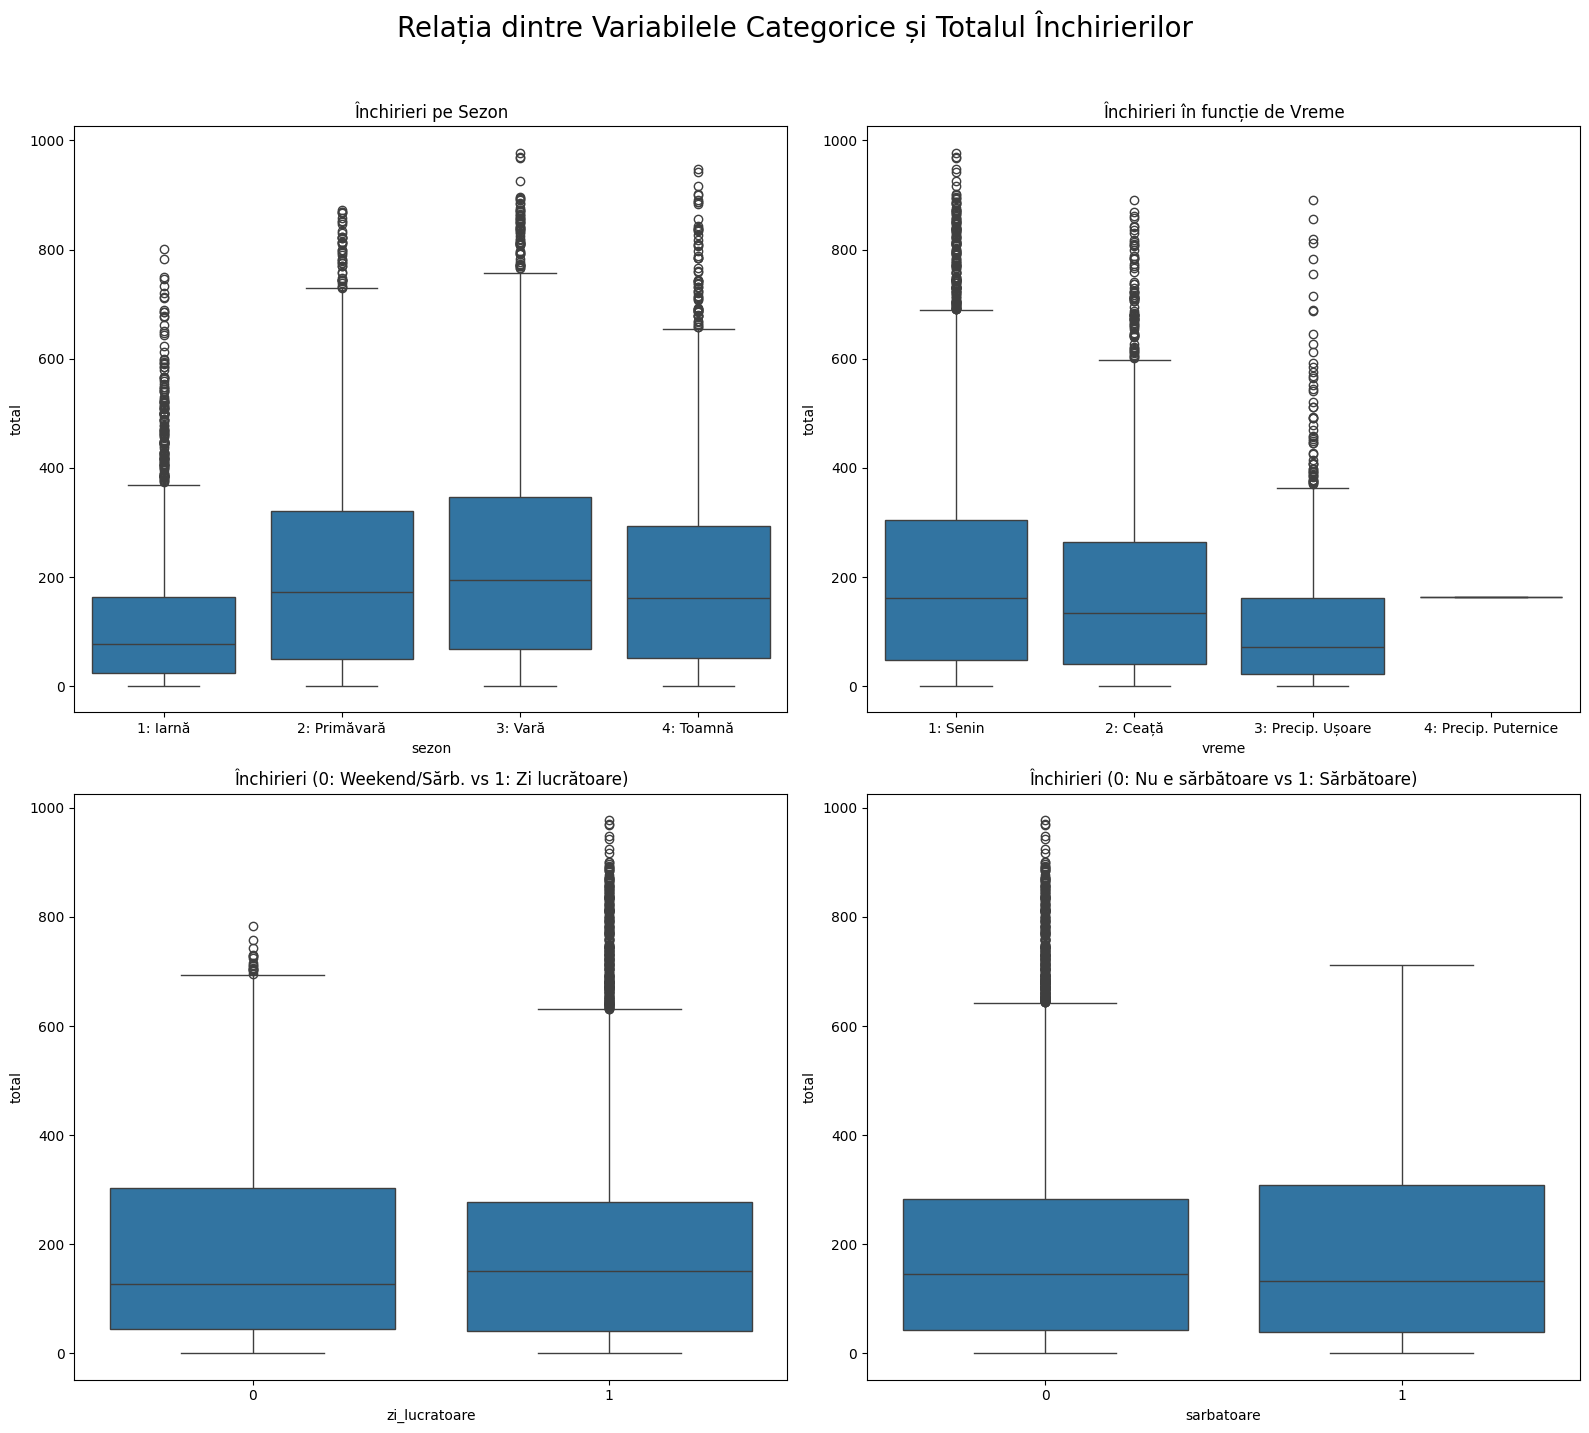

In [9]:
df_reset = df.reset_index()
    
df_reset['ora'] = df_reset['data_ora'].dt.hour
df_reset['luna'] = df_reset['data_ora'].dt.month
df_reset['zi_saptamana'] = df_reset['data_ora'].dt.day_name()
    
df_plot = df_reset.copy()
df_plot['sezon'] = df_plot['sezon'].map({1: '1: Iarnă', 2: '2: Primăvară', 3: '3: Vară', 4: '4: Toamnă'})
df_plot['vreme'] = df_plot['vreme'].map({1: '1: Senin', 2: '2: Ceață', 3: '3: Precip. Ușoare', 4: '4: Precip. Puternice'})
    
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))
fig.suptitle('Relația dintre Variabilele Categorice și Totalul Închirierilor', fontsize=20, y=1.02)
    
sns.boxplot(ax=axes[0, 0], data=df_plot, x='sezon', y='total', order=['1: Iarnă', '2: Primăvară', '3: Vară', '4: Toamnă'])
axes[0, 0].set_title('Închirieri pe Sezon')
    
sns.boxplot(ax=axes[0, 1], data=df_plot, x='vreme', y='total', order=['1: Senin', '2: Ceață', '3: Precip. Ușoare', '4: Precip. Puternice'])
axes[0, 1].set_title('Închirieri în funcție de Vreme')
    
sns.boxplot(ax=axes[1, 0], data=df_plot, x='zi_lucratoare', y='total')
axes[1, 0].set_title('Închirieri (0: Weekend/Sărb. vs 1: Zi lucrătoare)')
    
sns.boxplot(ax=axes[1, 1], data=df_plot, x='sarbatoare', y='total')
axes[1, 1].set_title('Închirieri (0: Nu e sărbătoare vs 1: Sărbătoare)')

    
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

### Grafic 6: Boxplot pentru ora

de aici rezulta ca in anumite intervale de timp sunt mai multe inchirieri -> naveta.

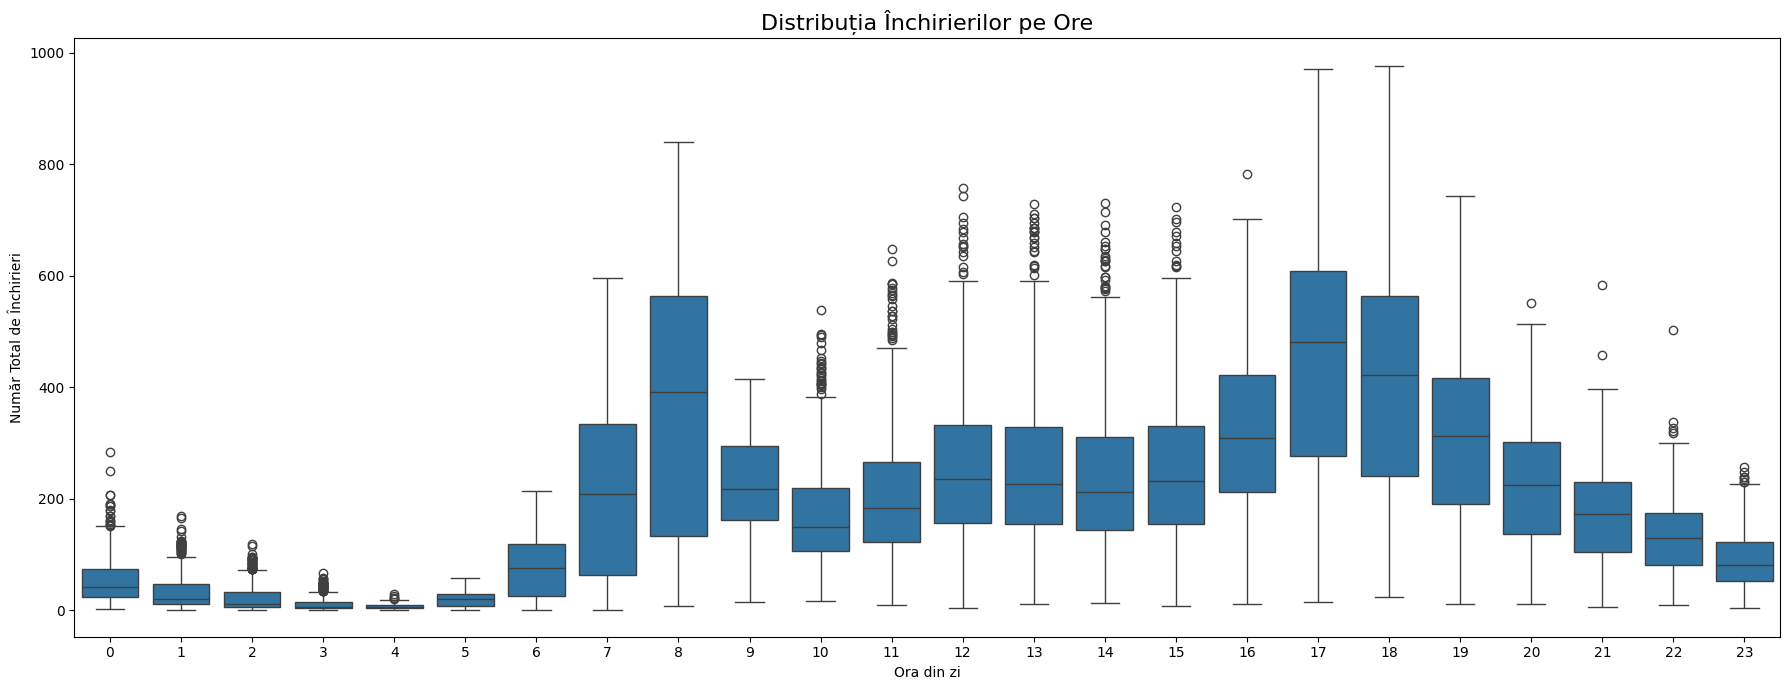

In [10]:
plt.figure(figsize=(18, 7))
sns.boxplot(data=df_plot, x='ora', y='total')
plt.title('Distribuția Închirierilor pe Ore', fontsize=16)
plt.xlabel('Ora din zi')
plt.ylabel('Număr Total de Închirieri')
plt.tight_layout()
plot_path_hourly = "hourly_boxplots.png"
plt.savefig(plot_path_hourly)

## Prelucrarea Atributelor

### Extragerea Atributelor

Trebuie sa dam drop la coloanele irelevante pentru setul de date

Acestea sunt: total (este coloana target), ocazionali, inregistrati, temperatura_resimtita.

De asemenea trebuiesc adaugate coloane pentru ora, luna, an si zi a saptamanii.

Transformarea in sin si cos a orei, lunii si zilei este datorata faptului ca desi ora 23:00 si ora 00:00 sunt apropiate, algoritmii nu vor sti asta.

In [11]:
def preprocess(df_in):
    df = df_in.copy()
    if 'data_ora' not in df.columns:
        df = df.reset_index()
    df["ora"] = df["data_ora"].dt.hour
    df["luna"] = df["data_ora"].dt.month
    df["zi_saptamana"] = df["data_ora"].dt.dayofweek

    df["hour_sin"] = np.sin(2 * np.pi * df["ora"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["ora"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["luna"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["luna"] / 12)
    df["dayofweek_sin"] = np.sin(2 * np.pi * df["zi_saptamana"] / 7)
    df["dayofweek_cos"] = np.cos(2 * np.pi * df["zi_saptamana"] / 7)

    drop_cols = ["data_ora", "ora", "luna", "zi_saptamana", "ocazionali", "inregistrati", "temperatura_resimtita"]

    df = df.drop(columns=[col for col in drop_cols if col in df.columns])
    return df


In [12]:
df_processed = preprocess(df)

df_processed = pd.get_dummies(df_processed, columns=["vreme"], prefix="vreme")

print("Datele au fost preprocesate.")
df_processed.head()

Datele au fost preprocesate.


,sezon,sarbatoare,zi_lucratoare,temperatura,umiditate,viteza_vant,total,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos,vreme_1,vreme_2,vreme_3,vreme_4
0,1,0,0,9.84,81,0.0,16,0.000000,1.000000,0.5,0.866025,-0.974928,-0.222521,True,False,False,False
1,1,0,0,9.02,80,0.0,40,0.258819,0.965926,0.5,0.866025,-0.974928,-0.222521,True,False,False,False
2,1,0,0,9.02,80,0.0,32,0.500000,0.866025,0.5,0.866025,-0.974928,-0.222521,True,False,False,False
3,1,0,0,9.84,75,0.0,13,0.707107,0.707107,0.5,0.866025,-0.974928,-0.222521,True,False,False,False
4,1,0,0,9.84,75,0.0,1,0.866025,0.500000,0.5,0.866025,-0.974928,-0.222521,True,False,False,False


### Impartirea datelor in train si test

In [13]:
target = "total"

X = df_processed.drop(columns=[target])
y = df_processed[target]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDimensiuni seturi de date (generate doar din train.csv):")
print(f" - X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f" - X_val: {X_val.shape}, y_val: {y_val.shape}")

print("\nPrimele 5 valori din y_val (target real):")
print(y_val.head())


Dimensiuni seturi de date (generate doar din train.csv):
 - X_train: (8708, 16), y_train: (8708,)
 - X_val: (2178, 16), y_val: (2178,)

Primele 5 valori din y_val (target real):
3133    127
5786     13
5224    163
8953    233
8054    222
Name: total, dtype: int64


## Pregatire Pipeline

### Alegerea feature-urilor

In [14]:
numeric_features = [
    'temperatura', 'umiditate', 'viteza_vant',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dayofweek_sin', 'dayofweek_cos'
]

categorical_features = ['sezon', 'sarbatoare', 'zi_lucratoare']

### Definire Pipeline

Pentru numeric features am ales StandardScaler pentru ca scaleaza datele astfel incat sa aiba media 0 si deviatia standard 1, ceea ce este util pentru multe algoritme de invatare automata.

Pentru categorical features am ales OneHotEncoder pentru ca transforma variabilele categorice in variabile binare, permitand modelelor sa le utilizeze făra a impune o ordine artificiala.


In [15]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)
print("\ndone")


done


### Aplicare pipeline

In [16]:
preprocessor.fit(X_train)
print("Preprocessor-ul a fost antrenat (fit) pe datele X_train.")
X_test = X_val
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Datele X_train și X_test au fost transformate.")

Preprocessor-ul a fost antrenat (fit) pe datele X_train.
Datele X_train și X_test au fost transformate.


### Rezultatele prelucrarii

In [17]:
print(f"Forma datelor de antrenament (X_train) înainte de transformare: {X_train.shape}")
print(f"Forma datelor de antrenament (X_train) DUPĂ transformare: {X_train_transformed.shape}")

try:
    feature_names_numeric = numeric_features
    feature_names_categorical = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    
    all_feature_names = list(feature_names_numeric) + list(feature_names_categorical)
    
    print(f"\nNumărul total de atribute după One-Hot Encoding: {len(all_feature_names)}")
    print("Exemplu de nume de atribute noi (primele 10):")
    print(all_feature_names[:10])

except Exception as e:
    print(f"Eroare la extragerea numelor atributelor: {e}")
    print("Afișare date transformate (primele 3 rânduri):")
    print(X_train_transformed[:3])

Forma datelor de antrenament (X_train) înainte de transformare: (8708, 16)
Forma datelor de antrenament (X_train) DUPĂ transformare: (8708, 21)

Numărul total de atribute după One-Hot Encoding: 17
Exemplu de nume de atribute noi (primele 10):
['temperatura', 'umiditate', 'viteza_vant', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'sezon_1']


## Antrenare modele

In [18]:
N_ITER = 4
CV_FOLDS = 3

### Definire pipeline-uri si parametri

in aceasta celula am definit pipeline-ul pentru fiecare algoritm si parametrii pe care ii vom testa mai departe.

In loc de Logistic Regression (care nu e aplicabil in cazul asta) am folosit Linear Regression.

In [19]:
#pipeline lr
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# pipeline svr
pipe_svr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVR())
])
params_svr = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf'],
}

# pipeline rfr
pipe_rfr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
params_rfr = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, None],
    'model__max_features': [1.0, 'sqrt', 'log2'],
}

#pipeline gradient boosting
pipe_gbr_sq = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42, loss='squared_error'))
])
params_gbr_sq = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15],
    'model__learning_rate': [0.01, 0.1, 0.2]
}

# pipeline gradient boosting quantile
pipe_gbr_q_median = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42, loss='quantile', alpha=0.5))
])
params_gbr_q = {
    'model__n_estimators': [100, 200], 
    'model__max_depth': [5, 10],
    'model__learning_rate': [0.01, 0.1]
}

#pipeline quantile regressor
pipe_qr_median = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', QuantileRegressor(quantile=0.5, solver='highs'))
])
params_qr = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0]
}


In [20]:
best_models = {}

pipelines_to_tune = {
    'SVR': pipe_svr,
    'RandomForestRegressor': pipe_rfr,
    'GradientBoostingRegressor_SquaredError': pipe_gbr_sq,
    'LinearRegression': pipe_lr
}

param_grids_to_tune = {
    'SVR': params_svr,
    'RandomForestRegressor': params_rfr,
    'GradientBoostingRegressor_SquaredError': params_gbr_sq,
    'LinearRegression': {}
}

### Cautare hiperparametri pentru SVR, RandomForrest si GBR_SquaredError

Pentru fiecare model si pipeline cautam cei mai buni parametri si adaugam cel mai bun model intr-un dictionar.

In [21]:
for name, pipe in pipelines_to_tune.items():
    print(f"\nSe tunează modelul: {name}...")
    
    search = RandomizedSearchCV(
        pipe, 
        param_grids_to_tune[name],
        n_iter=N_ITER, 
        cv=CV_FOLDS, 
        scoring='neg_mean_squared_error', 
        random_state=42, 
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)

    print(f"Cei mai buni parametri: {search.best_params_}")
    
    best_models[name] = search.best_estimator_



Se tunează modelul: SVR...


KeyboardInterrupt: 

### GradientBoostingRegressor (Quantile)

In [ ]:
search_gbr_q = RandomizedSearchCV(
    pipe_gbr_q_median, 
    params_gbr_q, 
    n_iter=N_ITER, 
    cv=CV_FOLDS, 
    scoring='neg_mean_squared_error',
    random_state=42, 
    n_jobs=-1
)
search_gbr_q.fit(X_train, y_train)
print(f"\nSe tunează modelul: GradientBoostingRegressor_Quantile...")
print(f"Cei mai buni parametri: {search_gbr_q.best_params_}")

model_params_gbr = {k.replace('model__', ''): v for k, v in search_gbr_q.best_params_.items()}



Se tunează modelul: GradientBoostingRegressor_Quantile...
Cei mai buni parametri: {'model__n_estimators': 200, 'model__max_depth': 10, 'model__learning_rate': 0.1}


### Antrenăm cele 3 modele (low, med, high) folosind parametrii optim

In [ ]:
# low
gbr_low_model = GradientBoostingRegressor(loss="quantile", alpha=0.05, random_state=42, **model_params_gbr)
pipe_gbr_low = Pipeline(steps=[('preprocessor', preprocessor), ('model', gbr_low_model)])
pipe_gbr_low.fit(X_train, y_train)

# median
pipe_gbr_med = search_gbr_q.best_estimator_ 

# high
gbr_high_model = GradientBoostingRegressor(loss="quantile", alpha=0.95, random_state=42, **model_params_gbr)
pipe_gbr_high = Pipeline(steps=[('preprocessor', preprocessor), ('model', gbr_high_model)])
pipe_gbr_high.fit(X_train, y_train)

best_models['GradientBoostingRegressor_Quantile'] = {
    'low': pipe_gbr_low,
    'median': pipe_gbr_med,
    'high': pipe_gbr_high
}

### Quantile Regressor

In [ ]:
search_qr = RandomizedSearchCV(
    pipe_qr_median, 
    params_qr, 
    n_iter=2, # ca asa am vrut eu
    cv=CV_FOLDS, 
    scoring='neg_mean_squared_error',
    random_state=42, 
    n_jobs=-1
)
search_qr.fit(X_train[:2000], y_train[:2000])
print(f"\nSe tunează modelul: QuantileRegressor...")
print(f"Cei mai buni parametri: {search_qr.best_params_}")

best_qr_params = search_qr.best_params_
best_alpha_qr = best_qr_params['model__alpha']


Se tunează modelul: QuantileRegressor...
Cei mai buni parametri: {'model__alpha': 0.01}


### Antrenarea modelelor low, median, high

In [ ]:
qr_low_model = QuantileRegressor(quantile=0.05, alpha=best_alpha_qr, solver='highs')
pipe_qr_low = Pipeline(steps=[('preprocessor', preprocessor), ('model', qr_low_model)])
pipe_qr_low.fit(X_train[:2000], y_train[:2000])

pipe_qr_med = search_qr.best_estimator_

qr_high_model = QuantileRegressor(quantile=0.95, alpha=best_alpha_qr, solver='highs')
pipe_qr_high = Pipeline(steps=[('preprocessor', preprocessor), ('model', qr_high_model)])
pipe_qr_high.fit(X_train[:2000], y_train[:2000])

print("Modelele QuantileRegressor (low, median, high) au fost antrenate.")

best_models['QuantileRegressor'] = {
    'low': pipe_qr_low,
    'median': pipe_qr_med,
    'high': pipe_qr_high
}

Modelele QuantileRegressor (low, median, high) au fost antrenate.


## Tabel final

In [ ]:
results_list = []
for name, model in best_models.items():
    if name.startswith('GradientBoostingRegressor_Quantile') or name.startswith('QuantileRegressor'):
        continue

    y_pred = model.predict(X_test)
    y_test = y_val
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results_list.append({
        "Algoritm": name,
        "MSE": mse,
        "MAE": mae,
        "R^2 Score": r2,
    })
    print(f"Evaluat: {name}")

for name, model in best_models.items():
    if name.startswith('GradientBoostingRegressor_Quantile'):
        y_pred_low = model['low'].predict(X_test)
        y_pred_med = model['median'].predict(X_test)
        y_pred_high = model['high'].predict(X_test)
        
        mse_low = mean_squared_error(y_test, y_pred_low)
        mae_low = mean_absolute_error(y_test, y_pred_low)
        r2_low = r2_score(y_test, y_pred_low)
        
        mse_med = mean_squared_error(y_test, y_pred_med)
        mae_med = mean_absolute_error(y_test, y_pred_med)
        r2_med = r2_score(y_test, y_pred_med)
        
        mse_high = mean_squared_error(y_test, y_pred_high)
        mae_high = mean_absolute_error(y_test, y_pred_high)
        r2_high = r2_score(y_test, y_pred_high)
        
        results_list.append({
            "Algoritm": name + " (Low Quantile)",
            "MSE": mse_low,
            "MAE": mae_low,
            "R^2 Score": r2_low,
        })
        results_list.append({
            "Algoritm": name + " (Median Quantile)",
            "MSE": mse_med,
            "MAE": mae_med,
            "R^2 Score": r2_med,
        })
        results_list.append({
            "Algoritm": name + " (High Quantile)",
            "MSE": mse_high,
            "MAE": mae_high,
            "R^2 Score": r2_high,
        })
        print(f"Evaluat: {name}")
    if name.startswith('QuantileRegressor'):
        y_pred_low = pipe_qr_low.predict(X_test)
        y_pred_med = pipe_qr_med.predict(X_test)
        y_pred_high = pipe_qr_high.predict(X_test)
        
        mse_low = mean_squared_error(y_test, y_pred_low)
        mae_low = mean_absolute_error(y_test, y_pred_low)
        r2_low = r2_score(y_test, y_pred_low)
        
        mse_med = mean_squared_error(y_test, y_pred_med)
        mae_med = mean_absolute_error(y_test, y_pred_med)
        r2_med = r2_score(y_test, y_pred_med)
        
        mse_high = mean_squared_error(y_test, y_pred_high)
        mae_high = mean_absolute_error(y_test, y_pred_high)
        r2_high = r2_score(y_test, y_pred_high)
        
        results_list.append({
            "Algoritm": name + " (Low Quantile)",
            "MSE": mse_low,
            "MAE": mae_low,
            "R^2 Score": r2_low,
        })
        results_list.append({
            "Algoritm": name + " (Median Quantile)",
            "MSE": mse_med,
            "MAE": mae_med,
            "R^2 Score": r2_med,
        })
        results_list.append({
            "Algoritm": name + " (High Quantile)",
            "MSE": mse_high,
            "MAE": mae_high,
            "R^2 Score": r2_high,
        })
        print(f"Evaluat: {name}")
results_df = pd.DataFrame(results_list)
print(results_df.to_markdown(index=False))

Evaluat: SVR
Evaluat: RandomForestRegressor
Evaluat: GradientBoostingRegressor_SquaredError
Evaluat: LinearRegression
Evaluat: GradientBoostingRegressor_Quantile
Evaluat: QuantileRegressor
| Algoritm                                             |      MSE |      MAE |   R^2 Score |
|:-----------------------------------------------------|---------:|---------:|------------:|
| SVR                                                  |  8881.04 |  56.5665 |    0.730934 |
| RandomForestRegressor                                |  4340.78 |  44.3683 |    0.868489 |
| GradientBoostingRegressor_SquaredError               |  4367.24 |  46.2526 |    0.867687 |
| LinearRegression                                     | 18012.6  |  95.1505 |    0.45428  |
| GradientBoostingRegressor_Quantile (Low Quantile)    | 18288.9  |  83.3234 |    0.445908 |
| GradientBoostingRegressor_Quantile (Median Quantile) |  4287.04 |  41.7021 |    0.870117 |
| GradientBoostingRegressor_Quantile (High Quantile)   |  9883.72 |

In [ ]:

from sklearn.model_selection import cross_validate

pd.set_option('display.max_colwidth', None)

final_stats = []

for name, model in best_models.items():
    current_model = model
    current_name = name
    
    if name == 'GradientBoostingRegressor_Quantile':
        current_model = model['median']
        current_name = "GBR Quantile (Median)"
    elif name == 'QuantileRegressor':
         current_model = pipe_qr_med 
         current_name = "Quantile Regressor (Median)"


    if hasattr(current_model, 'named_steps'):
        estimator_step = current_model.named_steps['model']
        all_params = estimator_step.get_params()

        relevant_keys = [
            'C', 'kernel', 'n_estimators', 'max_depth', 
            'learning_rate', 'alpha', 'loss', 'solver'
        ]
        str_params = {k: v for k, v in all_params.items() if k in relevant_keys and v is not None}
    else:
        str_params = "Default/Custom"

    print(f"Evaluare Cross-Validation pentru: {current_name}...")
    
    cv_results = cross_validate(
        current_model, 
        X_train, 
        y_train, 
        cv=3,
        scoring={
            'mse': 'neg_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2'
        }
    )
    
    mse_mean = -np.mean(cv_results['test_mse'])
    mse_var = np.var(cv_results['test_mse'])
    
    mae_mean = -np.mean(cv_results['test_mae'])
    mae_var = np.var(cv_results['test_mae'])
    
    r2_mean = np.mean(cv_results['test_r2'])
    r2_var = np.var(cv_results['test_r2'])

    final_stats.append({
        "Algoritm": current_name,
        "Hiper-parametri": str(str_params),
        "MSE (Mean)": mse_mean,
        "MSE (Var)": mse_var,
        "MAE (Mean)": mae_mean,
        "MAE (Var)": mae_var,
        "R2 (Mean)": r2_mean,
        "R2 (Var)": r2_var
    })

# Creare DataFrame
df_results = pd.DataFrame(final_stats)

def highlight_best(data):
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    
    for col in ['MSE (Mean)', 'MAE (Mean)']:
        if col in data.columns:
            min_val = data[col].min()
            styles[col] = data[col].apply(lambda x: 'font-weight: bold; background-color: #d1e7dd' if x == min_val else '')

    if 'R2 (Mean)' in data.columns:
        max_val = data['R2 (Mean)'].max()
        styles['R2 (Mean)'] = data['R2 (Mean)'].apply(lambda x: 'font-weight: bold; background-color: #d1e7dd' if x == max_val else '')
        
    return styles

format_dict = {
    "MSE (Mean)": "{:.2f}", "MSE (Var)": "{:.2f}",
    "MAE (Mean)": "{:.4f}", "MAE (Var)": "{:.4f}",
    "R2 (Mean)": "{:.4f}", "R2 (Var)": "{:.6f}"
}
print("\n=== Tabelul Final de Evaluare (Medie și Varianță pe Train CV) ===")
display(df_results.style.apply(highlight_best, axis=None).format(format_dict))

print(df_results.to_markdown(index=False))

Evaluare Cross-Validation pentru: SVR...
Evaluare Cross-Validation pentru: RandomForestRegressor...
Evaluare Cross-Validation pentru: GradientBoostingRegressor_SquaredError...
Evaluare Cross-Validation pentru: LinearRegression...
Evaluare Cross-Validation pentru: GBR Quantile (Median)...
Evaluare Cross-Validation pentru: Quantile Regressor (Median)...

=== Tabelul Final de Evaluare (Medie și Varianță pe Train CV) ===


,Algoritm,Hiper-parametri,MSE (Mean),MSE (Var),MAE (Mean),MAE (Var),R2 (Mean),R2 (Var)
0,SVR,"{'C': 100, 'kernel': 'rbf'}",9812.56,58478.79,59.3443,0.9518,0.7004,0.000020
1,RandomForestRegressor,"{'max_depth': 20, 'n_estimators': 100}",4783.34,4203.80,45.4271,0.1010,0.8540,0.000002
2,GradientBoostingRegressor_SquaredError,"{'alpha': 0.9, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 5, 'n_estimators': 100}",4576.36,2925.80,46.5860,0.1528,0.8603,0.000001
3,LinearRegression,{},18098.37,75420.29,96.0734,1.6041,0.4474,0.000101
4,GBR Quantile (Median),"{'alpha': 0.5, 'learning_rate': 0.1, 'loss': 'quantile', 'max_depth': 10, 'n_estimators': 200}",4611.11,16801.36,43.1289,0.1109,0.8592,0.000006
5,Quantile Regressor (Median),"{'alpha': 0.01, 'solver': 'highs'}",20183.46,84543.96,91.0503,0.9014,0.3837,0.000061


| Algoritm                               | Hiper-parametri                                                                                    |   MSE (Mean) |   MSE (Var) |   MAE (Mean) |   MAE (Var) |   R2 (Mean) |    R2 (Var) |
|:---------------------------------------|:---------------------------------------------------------------------------------------------------|-------------:|------------:|-------------:|------------:|------------:|------------:|
| SVR                                    | {'C': 100, 'kernel': 'rbf'}                                                                        |      9812.56 |     58478.8 |      59.3443 |    0.951831 |    0.700439 | 1.99917e-05 |
| RandomForestRegressor                  | {'max_depth': 20, 'n_estimators': 100}                                                             |      4783.34 |      4203.8 |      45.4271 |    0.101005 |    0.853951 | 1.97884e-06 |
| GradientBoostingRegressor_SquaredError | {'alpha': 0.9, 'learning_rate': 0.1, 

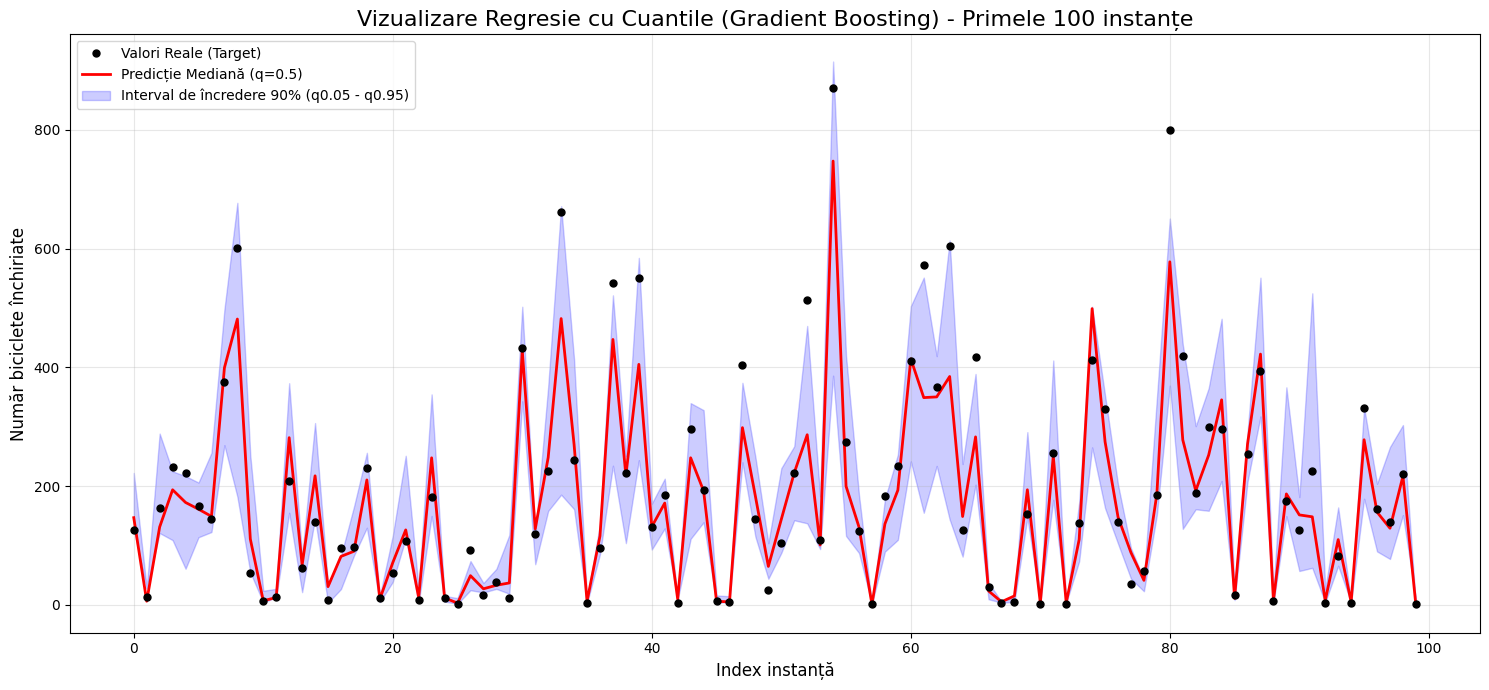

In [ ]:
import matplotlib.pyplot as plt

gbr_models = best_models['GradientBoostingRegressor_Quantile']

subset_size = 100
x_ax = range(subset_size)
y_true_subset = y_val[:subset_size].values

pred_low = gbr_models['low'].predict(X_val[:subset_size])
pred_med = gbr_models['median'].predict(X_val[:subset_size])
pred_high = gbr_models['high'].predict(X_val[:subset_size])

plt.figure(figsize=(15, 7))
plt.plot(x_ax, y_true_subset, 'k.', label='Valori Reale (Target)', markersize=10, zorder=10)
plt.plot(x_ax, pred_med, 'r-', label='Predicție Mediană (q=0.5)', linewidth=2)
plt.fill_between(x_ax, pred_low, pred_high, color='blue', alpha=0.2, label='Interval de încredere 90% (q0.05 - q0.95)')

plt.title('Vizualizare Regresie cu Cuantile (Gradient Boosting) - Primele 100 instanțe', fontsize=16)
plt.xlabel('Index instanță', fontsize=12)
plt.ylabel('Număr biciclete închiriate', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('quantile_regression_analysis.png')
plt.show()

## Best Features

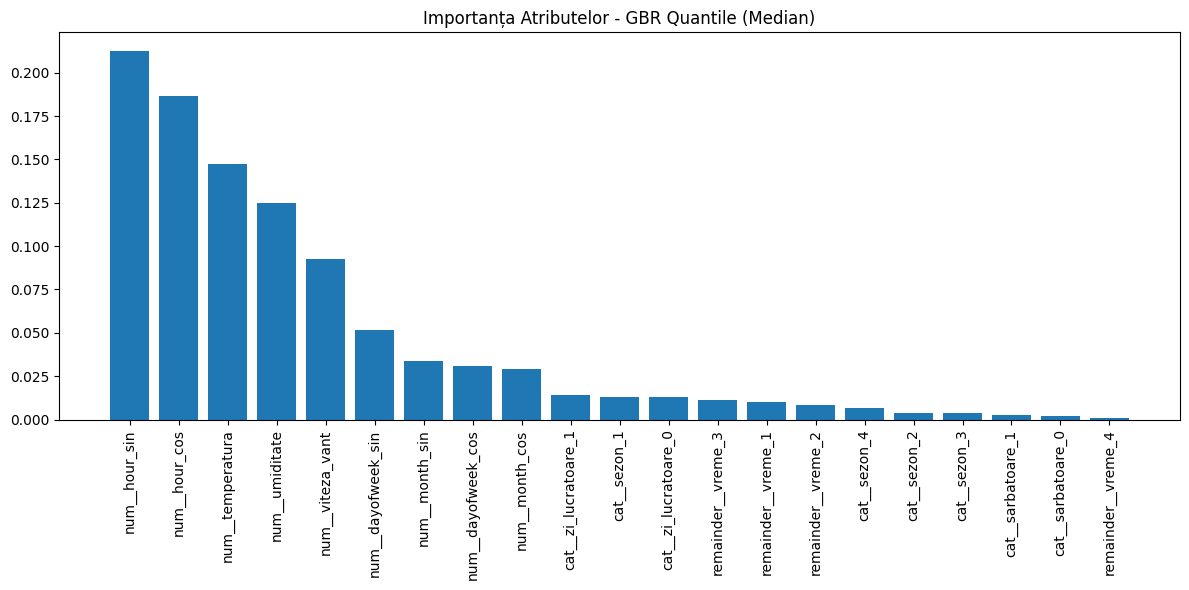

In [ ]:
importances = gbr_models['median'].named_steps['model'].feature_importances_
feature_names = preprocessor.get_feature_names_out()
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Importanța Atributelor - GBR Quantile (Median)")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.savefig('gbr_quantile_median_feature_importance.png')
plt.show()